In [2]:
from PIL import Image 
from matplotlib import pyplot as plt 
import matplotlib as mpl 

import json 
mpl.rcParams['font.sans-serif'] = ['Times New Roman']
mpl.rcParams['axes.unicode_minus'] = False

import sys 

sys.path.append('..')
from train import TrainModel 
import torch 
from custom_dataset.dataset import predict_by_name_processing
import numpy as np 
import cv2 
import os 
from custom_dataset.adatasets import ADatasets

In [3]:
mode = "test"
target_files = []
source_files = []
start = 0 if mode == "train" else 300
end = 300 if mode == "train" else -1
for image_dir in ["/home/kathy/dataset/submit_a/G_image1/", "/home/kathy/dataset/submit_a/R_image1/"]:
    for file in os.listdir(image_dir)[start : end]:
        source_files.append(image_dir + file)
for image_dir in ["/home/kathy/dataset/submit_a/G_target1/", "/home/kathy/dataset/submit_a/R_target1/"]:
    for file in os.listdir(image_dir)[start : end]:
        target_files.append(image_dir + file)

In [4]:
with open('/home/kathy/projects/project_guo/ad_log.json', 'r', encoding = "utf8") as f:
    res = json.loads(f.read())
colors = [
    (0, 0, 0),    # 背景 - 黑色
    (0, 255, 0),  # 器官1 - 绿色
    (255, 0, 0),  # 器官2 - 蓝色
    (0, 0, 255),   # 器官3 - 红色
    (255, 255, 0)   # 器官4 - cyan
]
device = torch.device("cuda:0")
model = TrainModel.load_from_checkpoint(
    res["Ours"]["train_model"], 
    map_location=device
)

In [5]:
ad = ADatasets(mode = "test", return_dir=True)
folder, imgs, target = next(iter(ad))


In [6]:
'/home/kathy/dataset/submit_a/G_image1/patient46-4_label.gz_12.png'.split("/")[-1][:-3]

'patient46-4_label.gz_12.'

In [7]:
imgs.shape, target.shape 

(torch.Size([24, 1, 128, 128]), torch.Size([24, 1, 128, 128]))

In [8]:
imgs = imgs.to(model.device)
target = target.to(model.device)

In [9]:
output = model(imgs)
output.shape 

/home/kathy/anaconda3/envs/hkx/lib/python3.8/site-packages/torch/nn/functional.py:3722: UserWarning: nn.functional.upsample is deprecated. Use nn.functional.interpolate instead.
  warnings.warn("nn.functional.upsample is deprecated. Use nn.functional.interpolate instead.")


torch.Size([24, 5, 128, 128])

In [10]:
pred = output.argmax(dim = 1)

In [11]:
pred_mask = torch.zeros((6 * 128 , 4 * 128))
true_mask = torch.zeros((6 * 128 , 4 * 128))

In [12]:
target.shape , pred.shape 

(torch.Size([24, 1, 128, 128]), torch.Size([24, 128, 128]))

In [13]:
for i in range(6):
    for j in range(4):
        pred_mask[i * 128 : (i + 1) * 128, j * 128 : (j + 1) * 128] = pred[i * 4 + j ]
        true_mask[i * 128 : (i + 1) * 128, j * 128 : (j + 1) * 128] = target[i * 4 + j, 0 ]
        

In [14]:
pred_mask.shape 

torch.Size([768, 512])

In [15]:
img = plt.imread(folder)

In [16]:
img = img[:768, :512] 

In [17]:
background = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)


In [18]:
pred_mask.shape 

torch.Size([768, 512])

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


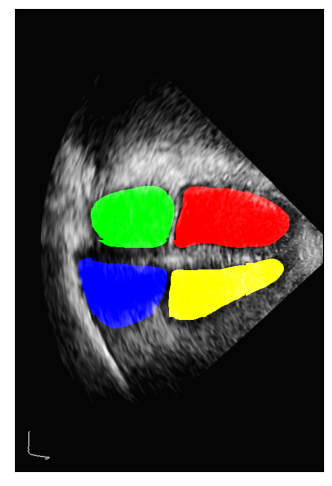

In [19]:
fig , axes = plt.subplots(1, 1)
fig.set_size_inches(6, 6)
overlay = np.ones(shape = (768, 512, 3))
# pred_mask = pred_mask.detach().cpu().numpy()
for i in range(1, 5):  # 假设类别从1到4
    overlay[pred_mask == i] = colors[i]

result = cv2.addWeighted(background, 0.98, overlay.astype("float32"), 0.02, 0)
axes.imshow(result)
axes.set_xticks([])
axes.set_yticks([])
plt.savefig(f"./output/pred.png", transparent=True, bbox_inches='tight')


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


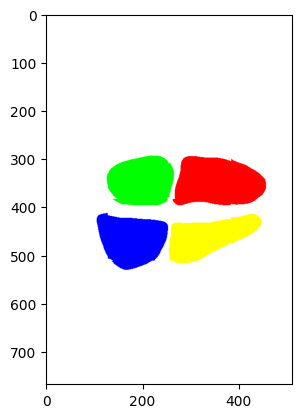

In [29]:
plt.imshow(overlay)